# Calibrate LeakyBucket model using scipy bounded optimisation

Calibrates the single `leakiness` parameter of the LeakyBucket model against
ERA5 forcing and Caravan observed discharge over the calibration period defined
in `settings.json`.

**Objective:** maximise KGE (Kling-Gupta Efficiency) → minimise `1 - KGE`.

**Optimiser:** `scipy.optimize.minimize_scalar` with `method='bounded'`.
One parameter, no heavy dependencies — no `sceua` needed.

**Output:**
- `{path_output}/{caravan_id}_LB_params_SCE.csv` — best leakiness value
- `results.json` — calibration KGE and NSE

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from rich import print

import ewatercycle
import ewatercycle.forcing

try:
    from scripts.leakybucket_model import LeakyBucketLocal
except ImportError:
    sys.path.insert(0, str(Path().resolve().parent))
    from scripts.leakybucket_model import LeakyBucketLocal

In [2]:
from hydrobm.metrics import calculate_metric

In [3]:
# Parameters — overridden by papermill when running on HPC
settings_path = "settings.json"

In [4]:
with open(settings_path, 'r') as f:
    settings = json.load(f)

display(settings)

{'caravan_id': 'camelsaus_102101A',
 'country': 'australia',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2049-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'koppen_raster_path': '/data/shared/climate-data/koppen_geiger/1991_2020/koppen_geiger_0p00833333.tif',
 'base_path': '/home/mmelotto/ewatercycleClimateImpact/HBV',
 'path_caravan': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan',
 'path_ERA5': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5',
 'path_DestinE': '/home/mmelotto/ewatercycleClimateImpa

In [5]:
# Skip if calibration output already exists
params_path = Path(settings['path_output']) / (settings['caravan_id'] + '_LB_params_SCE.csv')
need_to_run = not params_path.exists()

if not need_to_run:
    display(f'Calibration already complete: {params_path}')

## Load forcing and observations

In [6]:
# ERA5 forcing (LumpedMakkink) — used as model input
load_location = Path(settings['path_ERA5']) / "work" / "diagnostic" / "script"
ERA5_forcing_object = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
display(ERA5_forcing_object)

LumpedMakkinkForcing(start_time='1994-08-01T00:00:00Z', end_time='2014-07-31T00:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script'), shape=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script/camelsaus_102101A.shp'), filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_1994-2014.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_1994-2014.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1994-2014.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

In [7]:
# Load the caravan forcing object
caravan_data_object = ewatercycle.forcing.sources['CaravanForcing'].load(directory=settings['path_caravan'])
display(caravan_data_object)

CaravanForcing(start_time='1994-08-01T00:00:00Z', end_time='2014-07-31T00:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan'), shape=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan/camelsaus_102101A.shp'), filenames={'tasmin': 'camelsaus_102101A_1994-08-01_2014-07-31_tasmin.nc', 'tas': 'camelsaus_102101A_1994-08-01_2014-07-31_tas.nc', 'tasmax': 'camelsaus_102101A_1994-08-01_2014-07-31_tasmax.nc', 'Q': 'camelsaus_102101A_1994-08-01_2014-07-31_Q.nc', 'pr': 'camelsaus_102101A_1994-08-01_2014-07-31_pr.nc', 'evspsblpot': 'camelsaus_102101A_1994-08-01_2014-07-31_evspsblpot.nc'})

## Calibration objective and model runner

In [8]:
def calibrationObjective(model_output, observation, start_calibration, end_calibration, metric_name='rmse'):
    '''A function that takes in two dataFrames, interpolates the model output to the
    observations and calculates the average absolute difference between the two. '''

    # Combine the two in one dataFrame and interpolate, to make sure times match
    hydro_data = pd.concat([model_output.reindex(observation.index, method='ffill'), observation], axis=1,
                           keys=['model', 'observation'])

    # Only select the calibration period
    hydro_data = hydro_data[hydro_data.index > pd.to_datetime(pd.Timestamp(start_calibration).date())]
    hydro_data = hydro_data[hydro_data.index < pd.to_datetime(pd.Timestamp(end_calibration).date())]

    obs = hydro_data['observation'].to_numpy()
    sim = hydro_data['model'].to_numpy()

    metric_value = calculate_metric(obs, sim, metric_name)

    return metric_value

def objective_function_sorted_maximum(model_output, observation, start_calibration, end_calibration):
    calibration_start_time = pd.to_datetime(start_calibration)
    calibration_end_time = pd.to_datetime(end_calibration)

    model_output.index = model_output.index.tz_localize(None)  # Remove timezone
    observation.index = observation.index.tz_localize(None)
    start = calibration_start_time.tz_localize(None)
    end = calibration_end_time.tz_localize(None)

    model_aligned = model_output.reindex(observation.index, method='ffill')
    df = pd.concat({'model': model_aligned, 'observation': observation}, axis=1)
    df = df.loc[start:end].dropna()

    sim = df['model'].to_numpy()
    obs = df['observation'].to_numpy()

    # Sort data from high to low
    sorted_model_data = np.sort(sim)[::-1]  # Sorteer aflopend
    sorted_obs_data = np.sort(obs)[::-1]

    #calculate return periods
    m = len(sorted_model_data)
    rank = np.arange(1, m + 1)
    return_periods_days_model = (m + 1) / rank
    # return_periods_years_model = return_periods_days_model / 365.25


    m = len(sorted_obs_data)
    rank = np.arange(1, m + 1)
    return_periods_days_obs = (m + 1) / rank
    # return_periods_years_obs = return_periods_days_obs / 365.25

    sorted_model_data_subset = sorted_model_data
    sorted_obs_data_subset = sorted_obs_data


    if len(sorted_model_data_subset) != len(sorted_obs_data_subset):
        print(len(sorted_model_data_subset), len(sorted_obs_data_subset))
        raise ValueError("observation and data not equal length")

    objective_this_model = np.sqrt(np.mean((sorted_model_data_subset - sorted_obs_data_subset)**2))

    if np.isnan(objective_this_model):
        return np.inf

    return objective_this_model

In [9]:
# First set minimum and maximum values on the parameters
p_min_initial = np.array([0.001])
p_max_initial = np.array([0.8])

# Set initial state values
s_0 = np.array([0])

In [10]:
# Print parameter names and bounds
param_names = ["Leakiness"]
display(list(zip(param_names, np.round(p_min_initial, decimals=3), np.round(p_max_initial, decimals=3))))

[('Leakiness', 0.001, 0.8)]

In [11]:
# Create a dataframe for the observations
ds_observation = xr.open_mfdataset([caravan_data_object['Q']]).to_pandas()
ds_observation = ds_observation['Q']

In [12]:
def runModel(params, forcing_object, observations, initial_state, start_calibration, end_calibration):
    # Create model object, notice the forcing object.
    model = LeakyBucketLocal(forcing=forcing_object)

    # Create config file in model.setup()
    config_file, _ = model.setup(leakiness=params[0], initial_storage=initial_state[0],
                                 start_time=start_calibration, end_time=end_calibration)
    # Initialize model
    model.initialize(config_file)
    # Run model, capture calculated discharge and timestamps
    Q_m = []
    time = []
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("discharge")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
    # Finalize model (shuts down container, frees memory)
    model.finalize()

    # Make a pandas series
    model_output = pd.Series(data=Q_m, name="modelled discharge", index=time)

    return model_output


def runModelReturnObjective(params, forcing_object, observations, initial_state, start_calibration, end_calibration):

    model_output = runModel(params, forcing_object, observations, initial_state, start_calibration, end_calibration)

    # kge = calibrationObjective(model_output, observations, start_calibration, end_calibration, metric_name='kge')

    # kge is best if high, so we do one minus kge to make sure the optimiser minimises correctly
    # score = 1 - kge

    score = objective_function_sorted_maximum(model_output, observations, start_calibration, end_calibration)

    return score

## Run optimisation

In [13]:
if need_to_run:
    # minimize_scalar passes a scalar, so wrap it in an array to match runModelReturnObjective
    result = minimize_scalar(
        lambda x: runModelReturnObjective(
            np.array([x]), ERA5_forcing_object, ds_observation, s_0,
            settings['calibration_start_date'], settings['calibration_end_date']
        ),
        bounds=(p_min_initial[0], p_max_initial[0]),
        method='bounded',
        options={'xatol': 1e-4, 'maxiter': 100},
    )

In [14]:
if need_to_run:
    # Access the optimization results — wrap scalar back into array for runModel compatibility
    best_params = np.array([result.x])
    best_function_value = result.fun
    num_iterations = result.nit
    num_function_evaluations = result.nfev

In [15]:
if need_to_run:
    display(best_function_value)

4.128156175755268

In [16]:
if need_to_run:
    model_output = runModel(best_params, ERA5_forcing_object, ds_observation, s_0,
                            settings['calibration_start_date'], settings['calibration_end_date'])

In [17]:
if need_to_run:
    # Calculate NSE for the calibration period using the best parameters
    best_nse = calibrationObjective(model_output, ds_observation,
                                    settings['calibration_start_date'], settings['calibration_end_date'],
                                    metric_name='nse')
    display(f"Calibration NSE: {best_nse}")

    best_kge = calibrationObjective(model_output, ds_observation,
                                    settings['calibration_start_date'], settings['calibration_end_date'],
                                    metric_name='kge')
    display(f"Calibration KGE: {best_kge}")

'Calibration NSE: 0.09331544969487882'

'Calibration KGE: 0.30953100598361505'

In [18]:
if need_to_run:
    # Create a dataframe for the observations
    ds_observation = xr.open_mfdataset([caravan_data_object['Q']]).to_pandas()

## Calibration plot

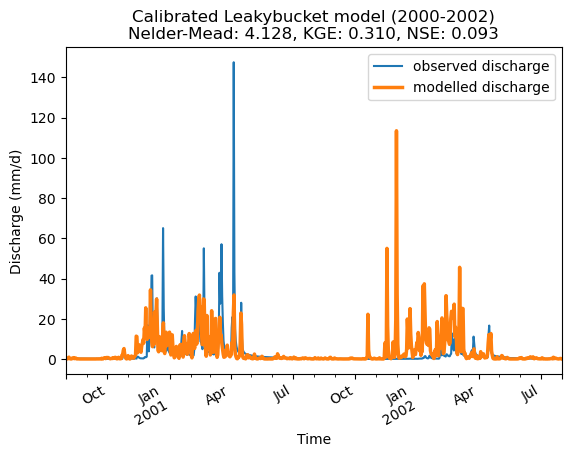

In [19]:
if need_to_run:
    # Zoom to 2 years starting from 2000-08-01
    start_time = pd.Timestamp('2000-08-01')
    zoom_end = start_time + pd.DateOffset(years=2)

    obs_zoom = ds_observation["Q"].loc[start_time:zoom_end]
    model_zoom = model_output.loc[start_time:zoom_end]

    # Make a plot of the model output
    obs_zoom.plot(label='observed discharge')
    model_zoom.plot(lw=2.5, label='modelled discharge')
    plt.title(f"Calibrated Leakybucket model (2000-2002)\nNelder-Mead: {(best_function_value):.3f}, KGE: {best_kge:.3f}, NSE: {best_nse:.3f}")
    plt.xlabel('Time')
    plt.ylabel("Discharge (mm/d)")
    plt.legend()
    plt.savefig(settings["figure_output"] + "/calibration_leakybucket.png")
    plt.show()

## Save results

In [20]:
if need_to_run:
    # Save to csv file
    np.savetxt(Path(settings["path_output"]) / (settings['caravan_id'] + "_LB_params_SCE.csv"), best_params, delimiter=",")

In [23]:
if need_to_run:
    # Save calibration KGE and NSE to results.json (same directory as settings.json)
    results_path = Path(settings["results_path"])
    results = json.loads(results_path.read_text()) if results_path.exists() else {}

    results["calibration_leakybucket"] = {
        "Nelder-Mead": round(best_function_value, 4),  # should be close to 0
        "KGE": round(best_kge, 4),  # best if close to 1
        "NSE": round(best_nse, 4),  # best if close to 1
        "leakiness": round(float(best_params[0]), 6),
        "period": f"{settings['calibration_start_date'][:10]} / {settings['calibration_end_date'][:10]}",
    }

    results_path.write_text(json.dumps(results, indent=4))
    print(f"Calibration Nelder-Mead = {results['calibration_leakybucket']['Nelder-Mead']}, Calibration KGE = {results['calibration_leakybucket']['KGE']}, NSE = {results['calibration_leakybucket']['NSE']} written to {results_path}")

Calibration Nelder-Mead = 4.1282, Calibration KGE = 0.3095, NSE = 0.0933 written to results.json

In [22]:
# Remove all temporary directories made by the model
!rm -rf leakybucketlocal*